# Nhiệm vụ 7 — Đánh giá chất lượng cụm Ward

**Mục tiêu:** Đánh giá chất lượng hình học của Ward tại **Global K=2** trên 15 development snapshots bằng Silhouette, Davies–Bouldin, Calinski–Harabasz, Inertia và Cluster Balance.

Notebook chỉ đọc `diagnostics.csv` đã đóng băng từ Nhiệm vụ 5. Notebook không fit lại Ward, không chọn lại K, không đọc dữ liệu M1 và không truy cập final holdout.


In [5]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "M2" / "Ke_hoach_M2_Phan_cum_co_phieu.md").exists(): return candidate
    raise RuntimeError("Repository root not found")

ROOT=find_repo_root(); WARD_DIR=ROOT/"M2/artifacts/m2-task5-ward-v1"; EVAL_DIR=ROOT/"M2/artifacts/m2-evaluation-ward"
REPORT_PATH=ROOT/"M2/reports/Bao_cao_M2_Nhiem_vu_7_Chat_luong_cum_Ward.md"; EVAL_DIR.mkdir(parents=True,exist_ok=True)
diagnostics=pd.read_csv(WARD_DIR/"diagnostics.csv")
required=["calinski_harabasz","cluster_balance","cluster_sizes","converged","davies_bouldin","inertia","k","silhouette","snapshot_date"]
assert list(diagnostics.columns)==required and len(diagnostics)==105
assert set(diagnostics["k"])==set(range(2,9))
ward_k2=diagnostics.loc[diagnostics["k"].eq(2)].sort_values("snapshot_date").reset_index(drop=True)
metrics=["silhouette","davies_bouldin","calinski_harabasz","inertia","cluster_balance"]
assert len(ward_k2)==15 and ward_k2["snapshot_date"].nunique()==15
assert ward_k2["converged"].eq(True).all() and ward_k2[metrics].notna().all().all()
def parse_sizes(value):
    parsed=json.loads(value) if isinstance(value,str) else value
    return [int(x) for x in (parsed.values() if isinstance(parsed,dict) else parsed)]
ward_k2["sizes"]=ward_k2["cluster_sizes"].map(parse_sizes)
ward_k2["n_eligible"]=ward_k2["sizes"].map(sum); ward_k2["smallest_cluster"]=ward_k2["sizes"].map(min)
ward_k2["largest_cluster"]=ward_k2["sizes"].map(max); ward_k2["pct_small"]=ward_k2["smallest_cluster"]/ward_k2["n_eligible"]
print("Input: M2/artifacts/m2-task5-ward-v1/diagnostics.csv")
print("PASS: K=2 has 15/15 converged snapshots with complete metrics.")


Input: M2/artifacts/m2-task5-ward-v1/diagnostics.csv
PASS: K=2 has 15/15 converged snapshots with complete metrics.


## Hai bảng chuẩn

Bảng 1 tổng hợp Mean, Median, Minimum và Maximum; Median là thống kê chính để chuyển sang Nhiệm vụ 10. Bảng 2 giữ đủ 15 snapshot K=2, kể cả tháng có kết quả thấp.


In [6]:
summary_rows=[]
for metric in metrics:
    values=ward_k2[metric].dropna()
    summary_rows.append({"metric":metric,"n_total":len(ward_k2),"n_available":len(values),"mean":values.mean(),"median":values.median(),"minimum":values.min(),"maximum":values.max()})
quality_summary=pd.DataFrame(summary_rows)[["metric","n_total","n_available","mean","median","minimum","maximum"]]
quality_summary.to_csv(EVAL_DIR/"quality_summary.csv",index=False)
detail_table=ward_k2[["snapshot_date","silhouette","davies_bouldin","calinski_harabasz","inertia","cluster_balance"]].rename(columns={"snapshot_date":"Snapshot","silhouette":"Silhouette","davies_bouldin":"DB","calinski_harabasz":"CH","inertia":"Inertia","cluster_balance":"Balance"})
print("Table 1 - Ward K=2 quality summary (5 x 7)"); display(quality_summary)
print("Table 2 - Ward K=2 details (15 x 6)"); display(detail_table)
print("Wrote: M2/artifacts/m2-evaluation-ward/quality_summary.csv")


Table 1 - Ward K=2 quality summary (5 x 7)


,metric,n_total,n_available,mean,median,minimum,maximum
0,silhouette,15,15,0.763118,0.755722,0.458851,0.943929
1,davies_bouldin,15,15,0.578858,0.534333,0.267141,1.093217
2,calinski_harabasz,15,15,614.645839,316.391783,118.873252,1882.058299
3,inertia,15,15,61151.116169,2158.608251,1304.124507,419136.924313
4,cluster_balance,15,15,0.080491,0.067669,0.010292,0.223602


Table 2 - Ward K=2 details (15 x 6)


,Snapshot,Silhouette,DB,CH,Inertia,Balance
0,2023-11-30,0.762987,0.549272,210.950916,1304.124507,0.067669
1,2023-12-29,0.755722,0.493906,378.398170,1396.643410,0.089385
2,2024-01-31,0.695411,0.587799,233.930208,1520.946055,0.094972
3,2024-02-29,0.723123,0.513532,316.391783,1480.098520,0.094972
4,2024-03-29,0.524664,1.093217,118.873252,1649.370732,0.223602
5,2024-04-26,0.704479,0.590603,239.277992,1674.880177,0.075377
6,2024-05-31,0.558701,0.879652,164.635080,1909.424379,0.163158
7,2024-06-28,0.748492,0.534333,249.860699,2158.608251,0.048035
8,2024-07-31,0.458851,1.077800,119.007501,2464.520666,0.204878
9,2024-08-30,0.903261,0.475227,919.686722,122029.496743,0.036585


Wrote: M2/artifacts/m2-evaluation-ward/quality_summary.csv


## Năm biểu đồ chất lượng

Mỗi biểu đồ dùng cùng 15 snapshot và có đường Median. Inertia chỉ là diagnostic bổ sung vì giá trị tuyệt đối phụ thuộc quy mô và phân tán của từng snapshot.


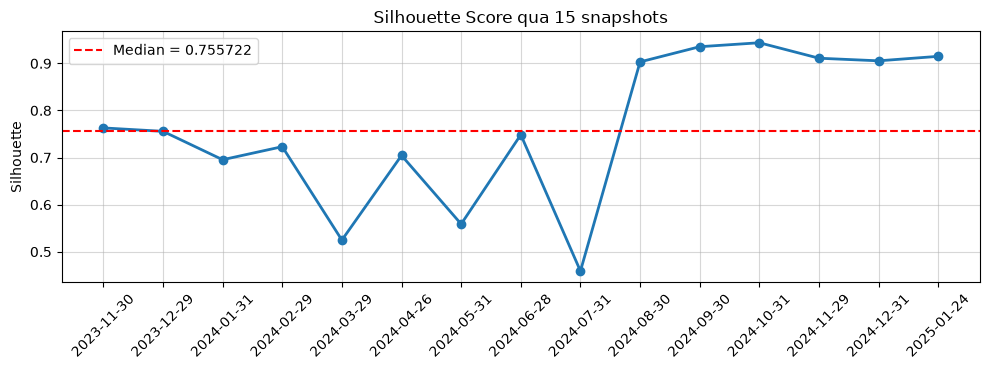

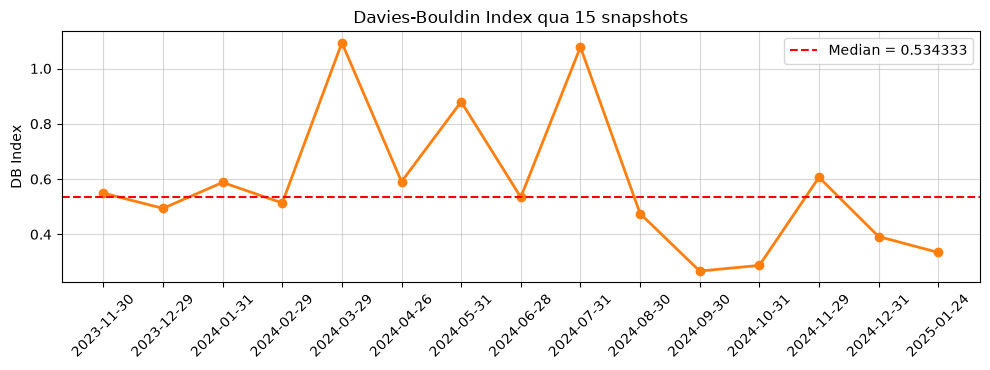

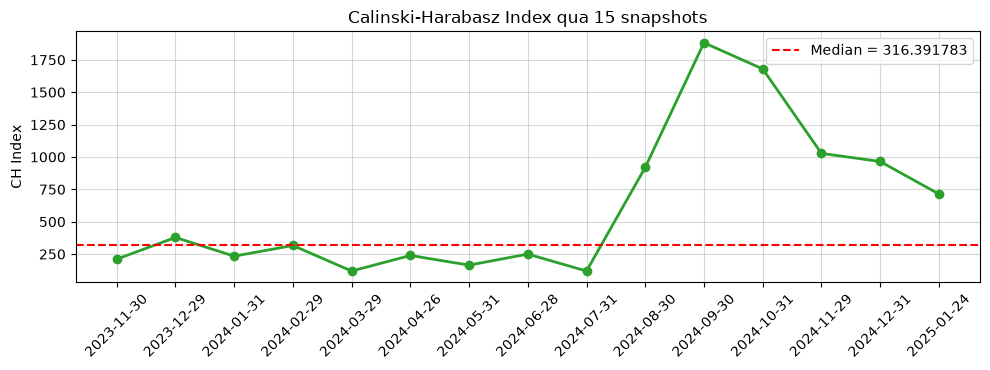

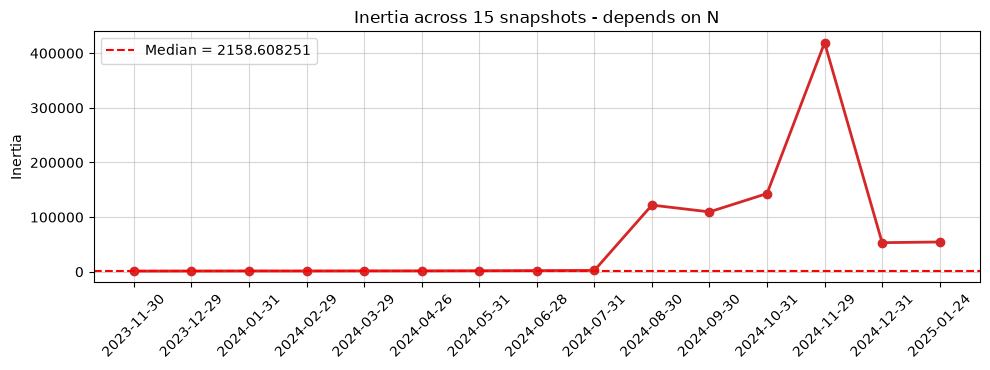

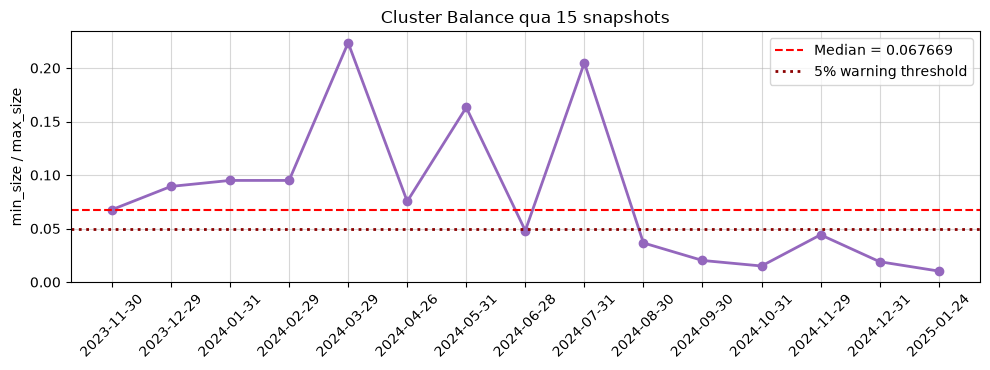

In [7]:
plot_specs=[("silhouette","Silhouette Score qua 15 snapshots","Silhouette","#1f77b4"),("davies_bouldin","Davies-Bouldin Index qua 15 snapshots","DB Index","#ff7f0e"),("calinski_harabasz","Calinski-Harabasz Index qua 15 snapshots","CH Index","#2ca02c"),("inertia","Inertia across 15 snapshots - depends on N","Inertia","#d62728"),("cluster_balance","Cluster Balance qua 15 snapshots","min_size / max_size","#9467bd")]
for metric,title,ylabel,color in plot_specs:
    fig,ax=plt.subplots(figsize=(10,3.8)); ax.plot(ward_k2["snapshot_date"],ward_k2[metric],marker="o",linewidth=2,color=color)
    med=ward_k2[metric].median(); ax.axhline(med,color="red",linestyle="--",linewidth=1.5,label=f"Median = {med:.6f}")
    if metric=="cluster_balance": ax.axhline(0.05,color="darkred",linestyle=":",linewidth=2,label="5% warning threshold")
    ax.set_title(title); ax.set_ylabel(ylabel); ax.tick_params(axis="x",rotation=45); ax.grid(True,alpha=0.5); ax.legend(); fig.tight_layout(); plt.show()


In [8]:
def markdown_table(frame):
    def render(value):
        if pd.isna(value):
            return ""
        if isinstance(value, float):
            return f"{value:.6f}"
        return str(value).replace("|", "\|")
    header = "| " + " | ".join(str(column).replace("|", "\\|") for column in frame.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(frame.columns)) + " |"
    rows = ["| " + " | ".join(render(value) for value in row) + " |" for row in frame.itertuples(index=False, name=None)]
    return "\n".join([header, separator, *rows])

report_detail = detail_table.copy()
report_text = f"""# Báo cáo M2 — Nhiệm vụ 7: Chất lượng cụm Ward

## Phạm vi và nguồn bằng chứng

- Ward Hierarchical, Global K=2 đã khóa ở Nhiệm vụ 3; 15 development snapshots từ 2023-11-30 đến 2025-01-24.
- Nguồn duy nhất: `M2/artifacts/m2-task5-ward-v1/diagnostics.csv`.
- Không fit lại model, không chọn lại K, không dùng return/Sharpe/ROI và không truy cập final holdout.

## Quy trình

Notebook đọc 105 dòng diagnostics K=2..8, lọc đúng 15 dòng K=2, kiểm tra hội tụ và tổng hợp năm metric với trọng số mỗi snapshot bằng nhau. Các giá trị K=3..8 là bằng chứng của giai đoạn khảo sát K; chúng không tham gia đánh giá Ward chính thức tại K=2.

## Kết quả tổng hợp

{markdown_table(quality_summary)}

## Kết quả từng snapshot

{markdown_table(report_detail)}

## Nhận định

- Median Silhouette = **{quality_summary.set_index('metric').loc['silhouette', 'median']:.6f}**, Median Davies–Bouldin = **{quality_summary.set_index('metric').loc['davies_bouldin', 'median']:.6f}**. Silhouette thấp nhất là **{quality_summary.set_index('metric').loc['silhouette', 'minimum']:.6f}** tại `{ward_k2.loc[ward_k2['silhouette'].idxmin(), 'snapshot_date']}`.
- Median Cluster Balance = **{quality_summary.set_index('metric').loc['cluster_balance', 'median']:.6f}**; mức thấp nhất **{quality_summary.set_index('metric').loc['cluster_balance', 'minimum']:.6f}**. Ward tạo cấu trúc bất đối xứng, nên Silhouette cao không đồng nghĩa hai cụm cân bằng.
- Median tỷ trọng cụm nhỏ trên toàn universe là khoảng **{ward_k2['pct_small'].median() * 100:.2f}%**. Dữ liệu xác nhận mất cân bằng; heavy-tail hoặc hành vi dòng tiền chỉ là giả thuyết cần bằng chứng riêng.
- Không so sánh Inertia tuyệt đối giữa các tháng có quy mô và phân tán khác nhau.

## Phán quyết và handoff

Ward đủ điều kiện kỹ thuật để đưa vào Nhiệm vụ 10, kèm cảnh báo mất cân bằng. Báo cáo chưa xếp hạng ba phương án, chưa chọn final method và không đưa ra khuyến nghị đầu tư.
"""
REPORT_PATH.write_text(report_text, encoding="utf-8")
print(f"Report written: {REPORT_PATH.relative_to(ROOT)}")

Report written: M2\reports\Bao_cao_M2_Nhiem_vu_7_Chat_luong_cum_Ward.md


<>:7: SyntaxWarning: invalid escape sequence '\|'
<>:7: SyntaxWarning: invalid escape sequence '\|'
C:\Users\phuon\AppData\Local\Temp\ipykernel_4800\708103628.py:7: SyntaxWarning: invalid escape sequence '\|'
  return str(value).replace("|", "\|")


## Kết luận ba phần

**A — Phán quyết kỹ thuật.** Median Silhouette = **0,755722** và Median Davies–Bouldin = **0,534333** cho thấy độ tách hình học tốt, nhưng Median Cluster Balance chỉ **0,067669** và Silhouette thấp nhất là **0,458851**.

**B — Bản chất cấu trúc.** Ward tạo phân hoạch bất đối xứng: median tỷ trọng cụm nhỏ khoảng **6,34%** universe. Kết quả xác nhận mất cân bằng, nhưng không tự chứng minh nguyên nhân kinh tế hay hành vi dòng tiền.

**C — Handoff.** Ward có thể chuyển sang Nhiệm vụ 10 với điều kiện cảnh báo mất cân bằng được giữ nguyên và đối chiếu cùng hồ sơ cụm, temporal stability của cả ba phương án.
